# Where is it cheap to travel right now?

A weak foreign currency does not by itself make a country cheap — local prices usually rise
along with the exchange rate. The World Bank already publishes the right measure, its
**price level index** (PPP over the market exchange rate, US = 100), but only annually and
more than a year late. This notebook anchors on that official series and nowcasts it to the
current month with IMF CPI and exchange rates: **the number of current US dollars needed
abroad to buy what $1 buys in the US**. Below 1.0 means a dollar goes further there.

See `README.md` for the reasoning and `src/real_travel_cost/` for the implementation.

In [1]:
import real_travel_cost as rtc

rtc.use_style()

# First call fetches from the IMF and caches; pass refresh=True to refetch.
panel = rtc.load_panel()
panel.tail()

,country_code,date,cpi,exr,country_name,advisory_level,local_in_usd,us_cpi,relative_prices,calibration,price_level_nowcast,current_dollars
42065,ZMB,2026-04-01,555.18,18.756786,Zambia,1,29.598888,152.722587,0.193808,211.033172,40.899957,0.409000
42066,ZMB,2026-05-01,556.26,18.352143,Zambia,1,30.310357,153.687020,0.197221,211.033172,41.620241,0.416202
42067,ZMB,2026-06-01,556.62,18.083571,Zambia,1,30.780424,153.150001,0.200982,211.033172,42.413911,0.424139
42068,ZMB,2026-07-01,557.46,18.793214,Zambia,1,29.662834,153.134408,0.193705,211.033172,40.878089,0.408781
42069,ZMB,2026-08-01,558.72,19.030000,Zambia,1,29.359958,153.134408,0.191727,211.033172,40.460698,0.404607


## Cost of living over time

<Axes: title={'left': 'Cost of living in current US dollars'}>

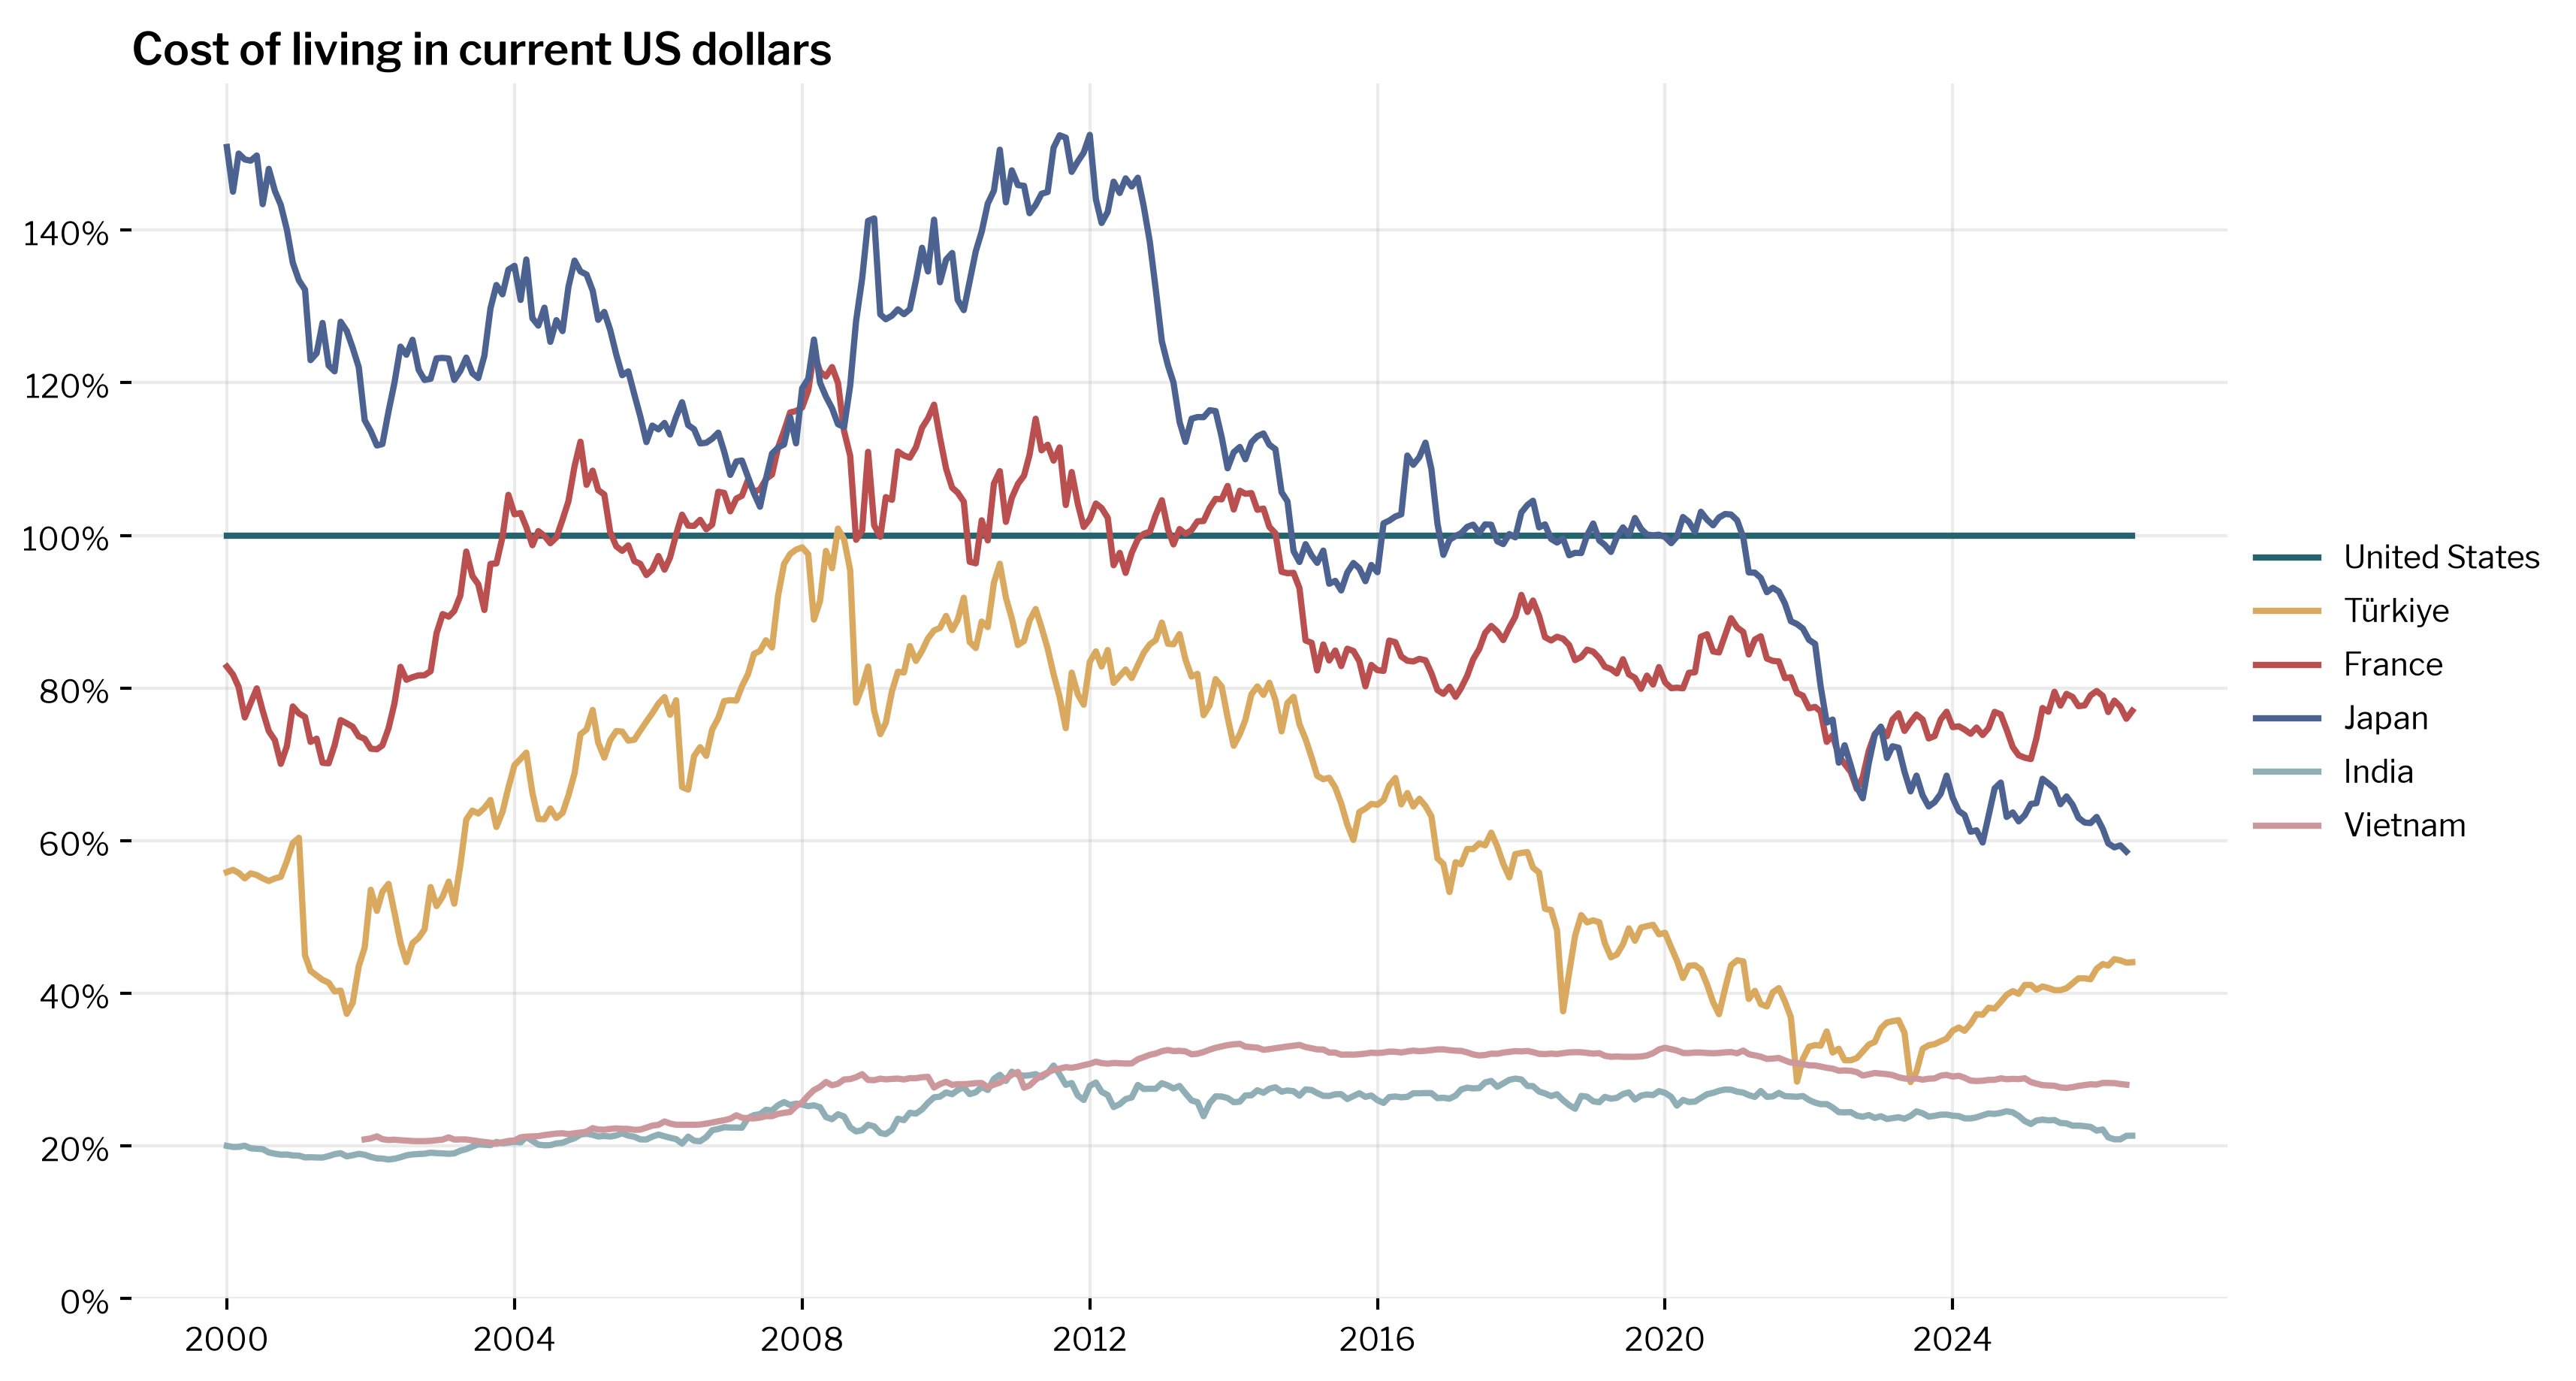

In [2]:
rtc.plot_series(
    panel,
    ["United States", "Türkiye", "France", "Japan", "India", "Vietnam"],
    title="Cost of living in current US dollars",
)

## The Türkiye case

The figure in the README: the lira's collapse on top, and what a dollar actually buys
underneath. The two panels tell opposite stories, which is the whole point.

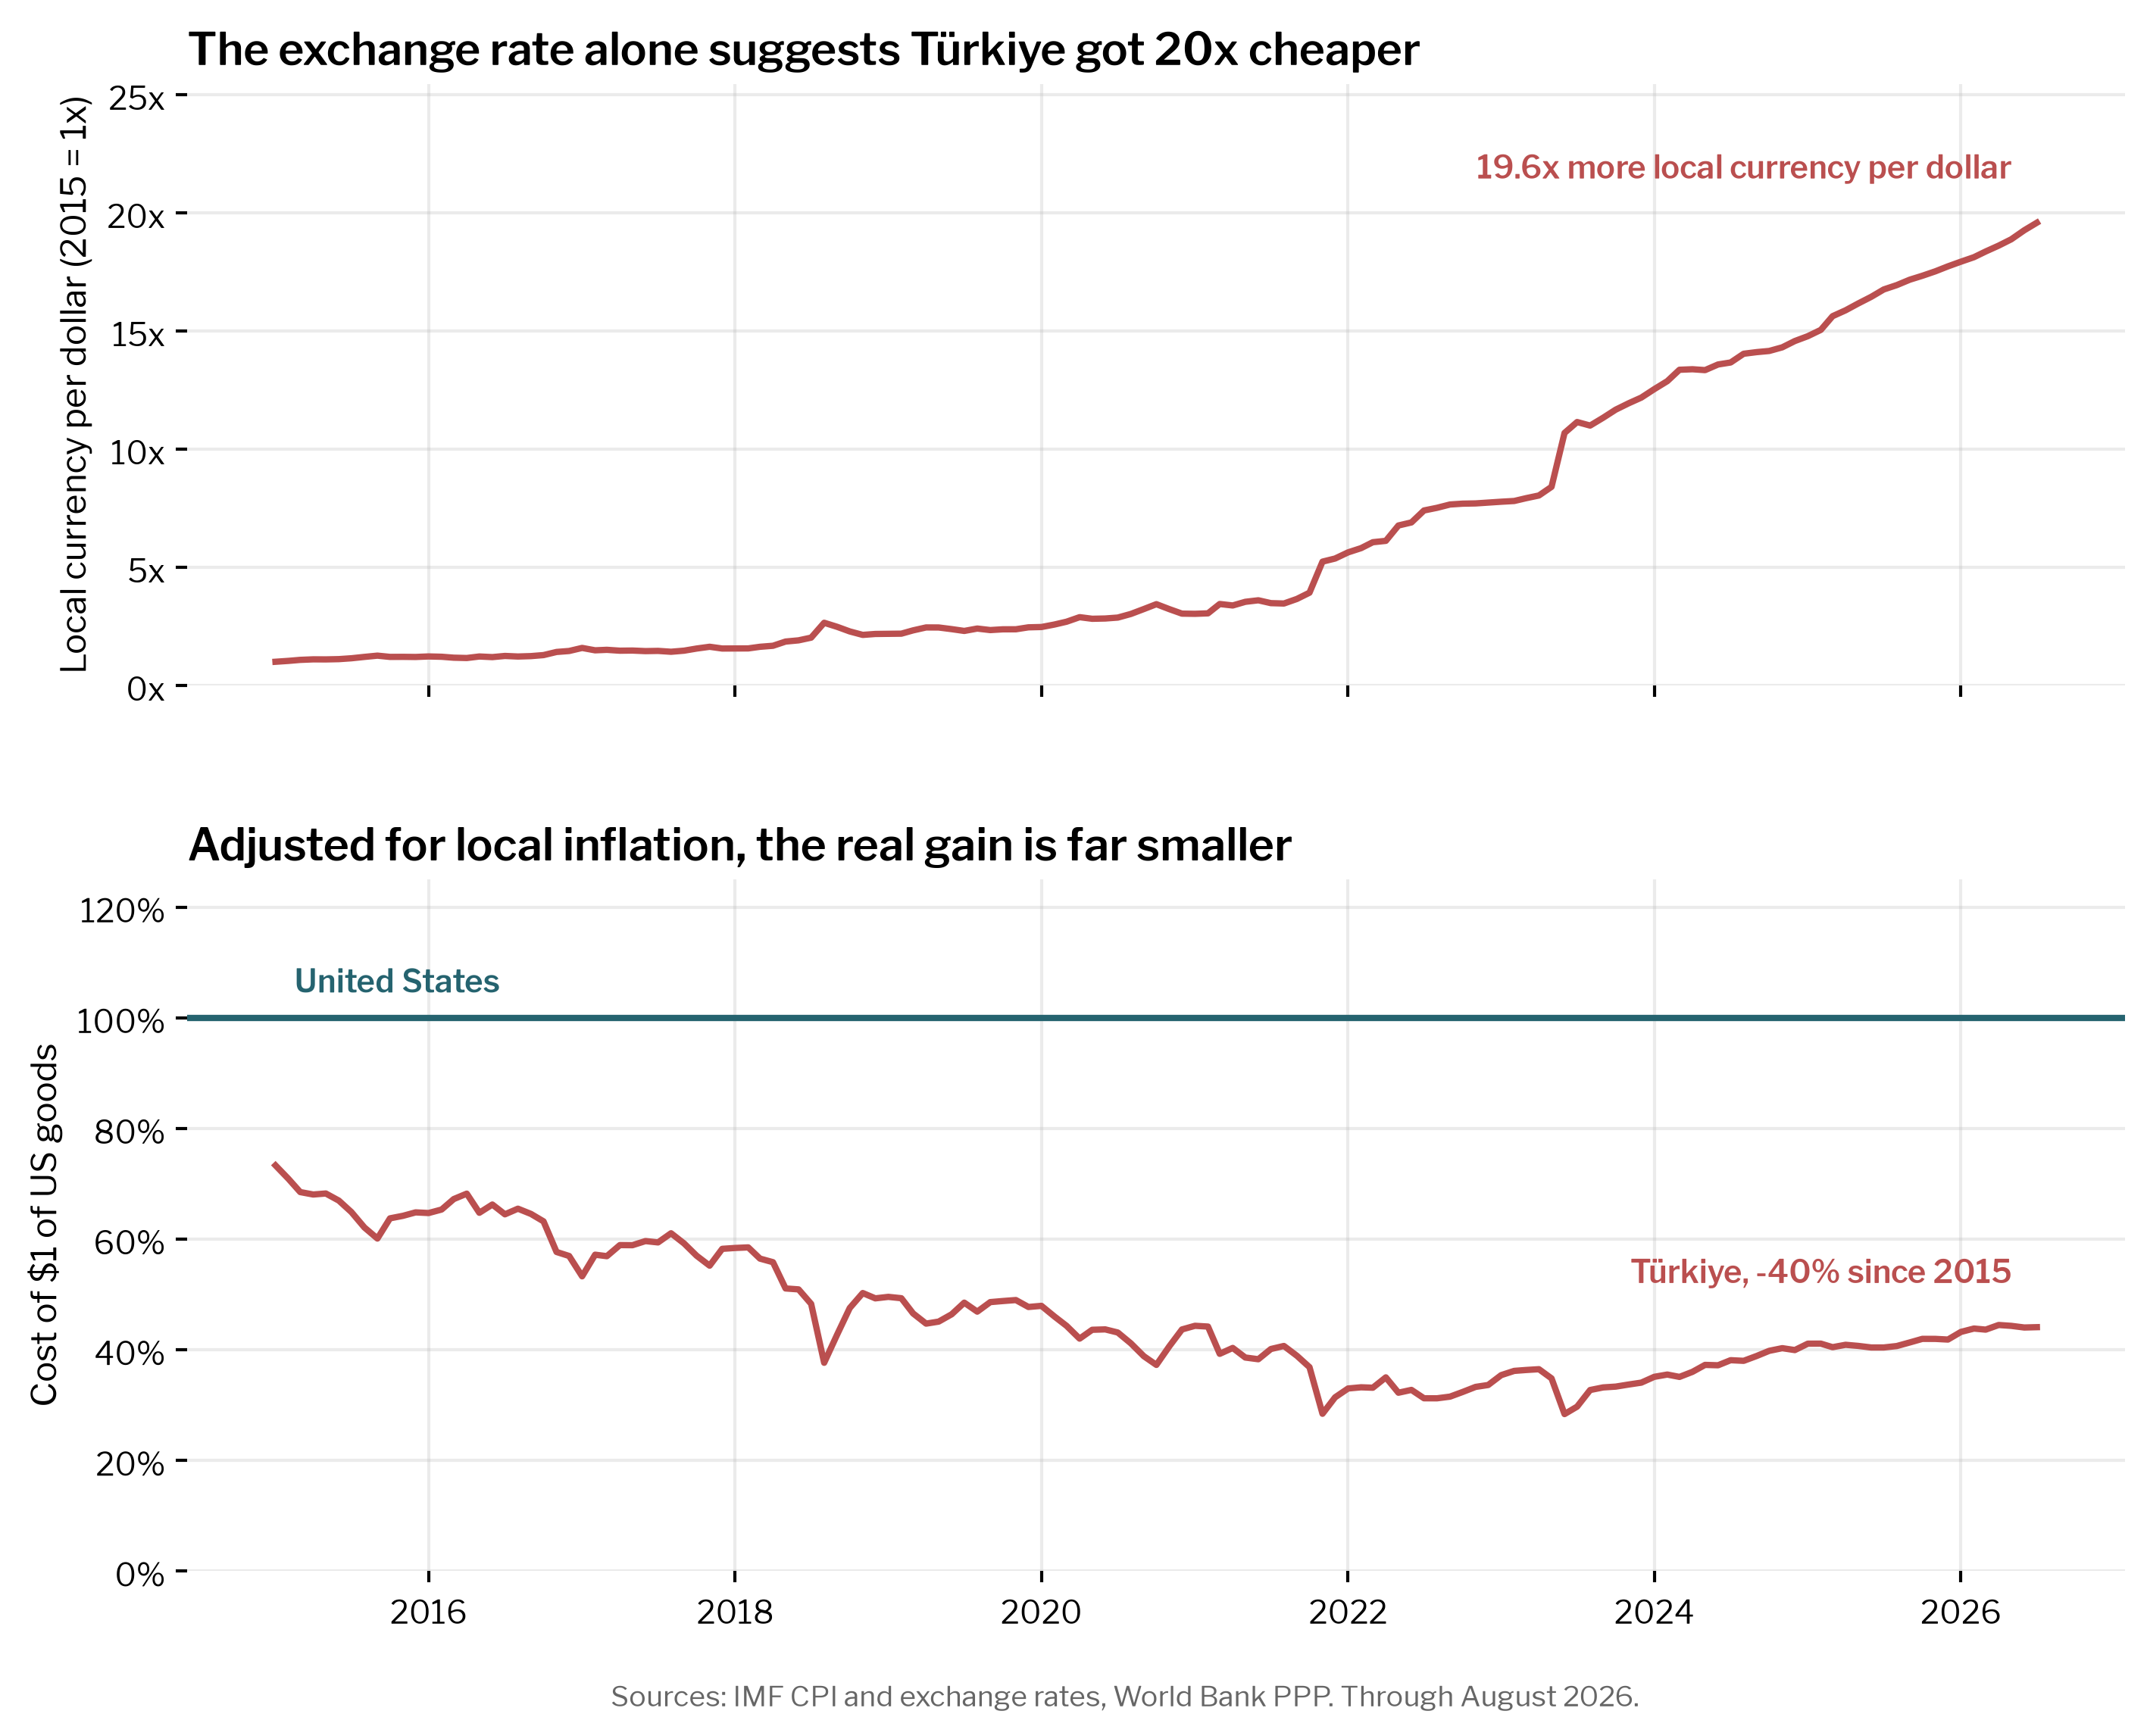

In [3]:
rtc.plot_devaluation_vs_real_cost(panel);

## Cheapest and most expensive today

Advisory levels 1-2 only. Countries report CPI on different lags, so each is shown at its
own latest month.

In [4]:
ranked = rtc.rank_latest(panel)

display(ranked.head(10))
display(ranked.tail(10))

,country_name,date,advisory_level,current_dollars
0,Egypt,2026-06-01,2,0.168180
1,Laos,2026-06-01,2,0.212453
2,India,2026-07-01,2,0.213453
3,Bhutan,2026-02-01,1,0.228334
4,Nepal,2026-03-01,2,0.233621
5,Indonesia,2026-07-01,2,0.260745
6,Bangladesh,2026-07-01,2,0.263430
7,East Timor,2026-06-01,2,0.270166
8,Sri Lanka,2026-06-01,2,0.272137
9,Vietnam,2026-06-01,1,0.280261


,country_name,date,advisory_level,current_dollars
103,Ireland,2026-07-01,1,0.861808
104,Netherlands,2026-08-01,2,0.870788
105,United Kingdom,2026-07-01,2,0.906120
106,Luxembourg,2026-07-01,1,0.939739
107,Australia,2026-07-01,1,0.989380
108,Norway,2026-07-01,1,0.989563
109,United States,2026-07-01,1,1.000000
110,Barbados,2026-06-01,1,1.075795
111,Switzerland,2026-07-01,1,1.116525
112,Iceland,2026-08-01,1,1.271856


## What has changed over the last decade?

Türkiye is the case from the README: the lira lost most of its value, yet domestic inflation
cancelled nearly all of the gain a dollar holder might have expected.

Note the advisory feed publishes only today's levels, so the filter here is "currently safe
places, priced historically" rather than a historical control.

In [5]:
changes = rtc.rank_change(panel, start="2015-07-01", end="2025-07-01")

print("Largest price increases:")
display(changes.head(10))
print("Largest price decreases:")
display(changes.tail(10))

Largest price increases:


,country_name,advisory_level,start,end,pct_change
0,São Tomé and Príncipe,2,0.299460,0.649194,1.167884
1,Moldova,2,0.239902,0.436693,0.820297
2,Albania,2,0.321039,0.465031,0.448520
3,Czechia,1,0.459098,0.605434,0.318745
4,Serbia,2,0.364856,0.459066,0.258212
5,Estonia,1,0.537883,0.673153,0.251485
6,Lithuania,1,0.477794,0.585414,0.225245
7,Iceland,1,0.995990,1.218496,0.223401
8,Armenia,2,0.316594,0.379749,0.199485
9,Bulgaria,1,0.391649,0.465011,0.187314


Largest price decreases:


,country_name,advisory_level,start,end,pct_change
111,South Korea,1,0.767505,0.586022,-0.236459
112,Brazil,2,0.605902,0.454602,-0.249710
113,Laos,2,0.299916,0.224979,-0.249859
114,Sri Lanka,2,0.399163,0.292875,-0.266276
115,China,2,0.647485,0.469796,-0.274430
116,Japan,1,0.927837,0.647768,-0.301852
117,Kazakhstan,1,0.480408,0.319506,-0.334929
118,Türkiye,2,0.648780,0.404103,-0.377133
119,Egypt,2,0.283057,0.153072,-0.459219
120,Uzbekistan,1,0.627091,0.288804,-0.539454


## Validation against the published series

The nowcast should reproduce the World Bank's own index where the two overlap. `ratio` is 1.0
where they agree; agreement decays the further a year sits from the anchor. An order-of-
magnitude outlier means a currency unit mismatch, not a finding.

In [6]:
price_level = rtc.fetch_price_level_index()
comparison = rtc.compare_to_official(panel, price_level, since=2023)

print(f"within 10%: {comparison.ratio.sub(1).abs().le(0.10).mean():.1%}")
comparison.reindex(comparison.ratio.sub(1).abs().sort_values().index).tail(10)

within 10%: 97.0%


,country_code,country_name,year,nowcast,price_level_index,ratio
179,GUY,Guyana,2023,32.927597,37.378402,0.880926
132,EGY,Egypt,2024,15.128082,17.458925,0.866496
263,LKA,Sri Lanka,2023,30.136249,26.291191,1.146249
32,BFA,Burkina Faso,2023,36.505201,31.619552,1.154514
389,SLE,Sierra Leone,2023,18.395934,22.495049,0.817777
326,NGA,Nigeria,2023,19.813188,24.550513,0.807038
24,BDI,Burundi,2024,14.623377,18.124521,0.806828
141,ETH,Ethiopia,2024,41.961123,34.440348,1.218371
23,BDI,Burundi,2023,14.247087,21.770076,0.654434
140,ETH,Ethiopia,2023,49.299192,34.465016,1.430413


## Coverage

Joins are on ISO-3 codes, except the State Dept. feed, which publishes names only.
Anything left unmatched below needs an entry in `countries.ADVISORY_NAME_TO_CODE`; the
remainder are territories with no IMF monthly CPI, which drop from the inner join anyway.

In [7]:
advisories = rtc.attach_country_codes(rtc.fetch_travel_advisories(), price_level)
rtc.unmatched(advisories)

0                              Anguilla
1                            Antarctica
2                               Bonaire
3                British Virgin Islands
4                               Curaçao
5        Federated States of Micronesia
6                         French Guiana
7                      French Polynesia
8                    French West Indies
9                                  Gaza
10                   Kingdom of Denmark
11    Mainland China, Hong Kong & Macau
12                                Nauru
13                        New Caledonia
14                                 Saba
15                       Sint Eustatius
16                         Sint Maarten
Name: country_name, dtype: str